# Bootstrapping & Visualizations

This notebook takes bootstrapping to the **next level** with:

- Bootstrapped confidence intervals with shaded plots
- Bias and variance estimation
- Comparing bootstrap distributions to normal approximations
- Animated-like evolution of bootstrap sample distributions
- Beautiful violin, swarm, and KDE visualizations

We use `seaborn`, `matplotlib`, and `scipy` to explore bootstrapping in depth.|

## Generate Synthetic Data
We'll create a realistic dataset to bootstrap (e.g., sample means of salaries).

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

sns.set(style='whitegrid', palette='muted')

np.random.seed(42)
salaries = np.concatenate([
    np.random.normal(60000, 5000, 300),
    np.random.normal(120000, 10000, 20)  # high earners (outliers)
])
df = pd.DataFrame({'Salary': salaries})
df

,Salary
0,62483.570765
1,59308.678494
2,63238.442691
3,67615.149282
4,58829.233126
...,...
315,120210.038416
316,126819.529713
317,116897.332434
318,123241.663525


## Bootstrapping 5000 Samples
We compute bootstrapped means and 95% confidence intervals.

In [26]:
boot_means = [np.mean(np.random.choice(df['Salary'], size=len(df), replace=True)) for _ in range(5000)]
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)
boot_mean = np.mean(boot_means)
print(f"Bootstrapped Mean: £{boot_mean:,.2f}")
print(f"95% CI: £{ci_lower:,.2f} to £{ci_upper:,.2f}")

Bootstrapped Mean: £63,892.38
95% CI: £62,236.08 to £65,728.48


## Bootstrap Distribution Plot
We overlay the confidence interval and normal distribution for comparison.

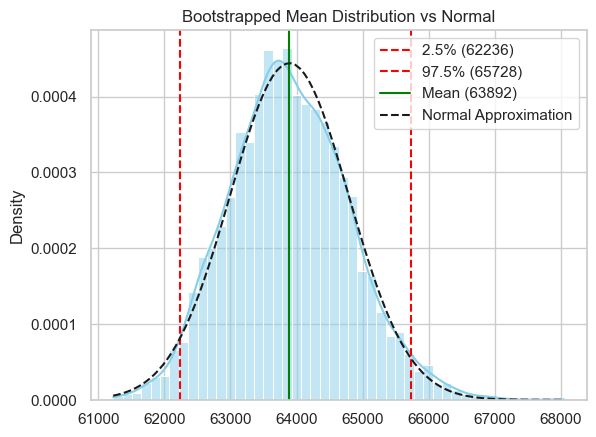

In [29]:
sns.histplot(boot_means, kde=True, color='skyblue', stat='density')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'2.5% ({ci_lower:.0f})')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'97.5% ({ci_upper:.0f})')
plt.axvline(boot_mean, color='green', linestyle='-', label=f'Mean ({boot_mean:.0f})')

# Overlay normal distribution
x = np.linspace(min(boot_means), max(boot_means), 100)
p = norm.pdf(x, np.mean(boot_means), np.std(boot_means))
plt.plot(x, p, 'k--', label='Normal Approximation')

plt.title('Bootstrapped Mean Distribution vs Normal')
plt.legend()
plt.show()

## Bias & Variance Estimation
We calculate bias and variance of the bootstrapped estimates.

In [32]:
original_mean = df['Salary'].mean()
bias = boot_mean - original_mean
variance = np.var(boot_means)
print(f"Original Mean: £{original_mean:,.2f}")
print(f"Bias: {bias:.2f}")
print(f"Variance: {variance:.2f}")

Original Mean: £63,896.12
Bias: -3.74
Variance: 806377.43


## Violin & Swarm Plot of Bootstraps
Visualize the spread and density of bootstrap samples.

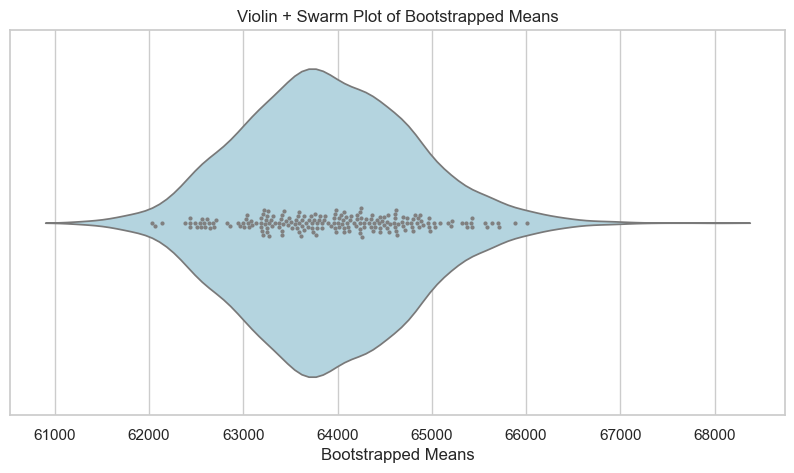

In [35]:
boot_df = pd.DataFrame({'Bootstrapped Means': boot_means})
plt.figure(figsize=(10,5))
sns.violinplot(data=boot_df, x='Bootstrapped Means', inner=None, color='lightblue')
sns.swarmplot(data=boot_df.sample(200), x='Bootstrapped Means', color='gray', size=3)
plt.title('Violin + Swarm Plot of Bootstrapped Means')
plt.show()

## Evolution of Bootstrap Distribution
We show how the distribution **stabilizes** as we increase the number of bootstrap samples.

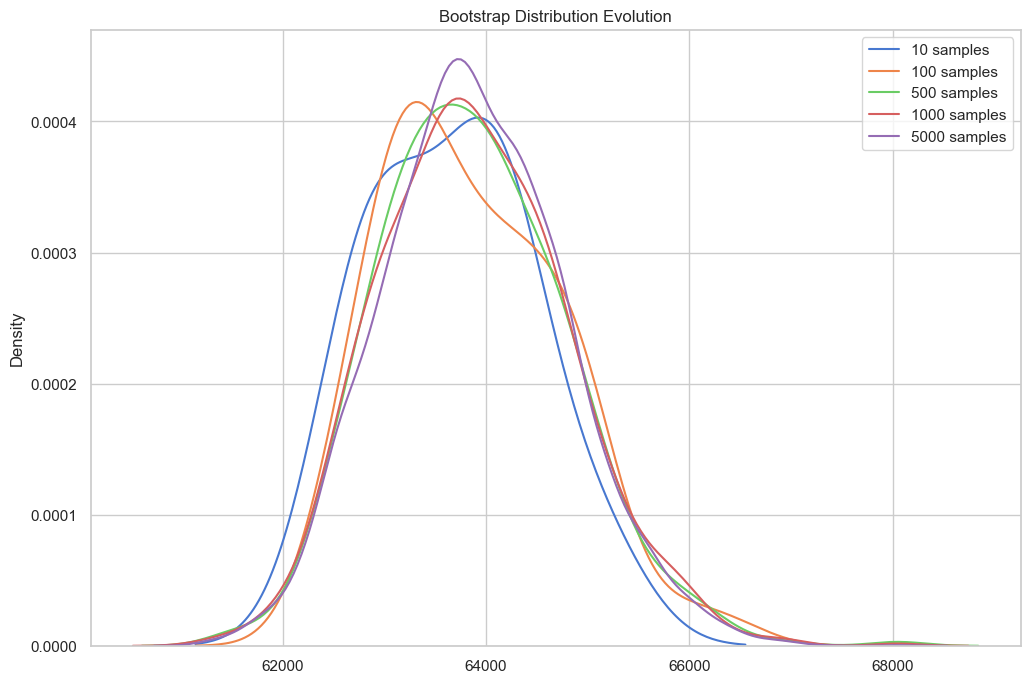

In [38]:
sample_sizes = [10, 100, 500, 1000, 5000]
plt.figure(figsize=(12,8))
for n in sample_sizes:
    subset = boot_means[:n]
    sns.kdeplot(subset, label=f'{n} samples')
plt.title('Bootstrap Distribution Evolution')
plt.legend()
plt.show()

## Conclusion
This advanced notebook covered:
- Bootstrapping with large samples
- Bias and variance diagnostics
- KDE, violin, and swarm plots
- Evolution of the bootstrap distribution

**Deeper insight + better visuals = better understanding**